# 03 - Posterior Analysis and Validation

**Author:** Rodrigo Antonio Salado Ferrero  
**Last Updated:** 2026-05-15

---

## Overview

This notebook performs in-depth analysis of the Bayesian calibration results
obtained in Notebook 02. The analysis focuses on:

1. **Convergence diagnostics** - R-hat, ESS, autocorrelation
2. **Parameter identifiability** - Correlations and posterior shapes
3. **Recovery assessment** - Comparison with true parameters (synthetic data)
4. **Posterior predictive validation** - Model fit quality
5. **Uncertainty quantification** - Credible intervals and prediction bands

## Key Questions

- Did the MCMC converge properly? (R-hat < 1.1, sufficient ESS)
- Are the true parameters recovered within credible intervals?
- Which parameters are well-identified vs. weakly identified?
- What are the correlations between parameters?
- Does the model fit the observed option prices?

---

## 1. Imports and Configuration

Load required libraries and configure plotting.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, norm
from typing import Tuple, Dict, Any, List, Optional
from dataclasses import dataclass
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Import local modules
import sys
sys.path.append('..')

from src.types import CalibrationResult, HestonParams, MarketData
from src.pricing import heston_call_prices, implied_volatility
from src.visualization import (
    set_style, plot_trace, plot_posterior_density,
    plot_pair_grid, plot_posterior_predictive, plot_calibration_summary,
    plot_autocorrelation, plot_ess
)
from src.inference import compute_r_hat, compute_ess

# Configure paths
RESULTS_DIR = Path("../results")
CHAINS_DIR = RESULTS_DIR / "chains"
FIGURES_DIR = RESULTS_DIR / "figures"
DATA_DIR = Path("../data/synthetic")

# Create directories if they don't exist
CHAINS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Configure plotting style
set_style(style="seaborn-v0_8-darkgrid", context="notebook", font_scale=1.0)

print(f"Chains directory: {CHAINS_DIR}")
print(f"Figures directory: {FIGURES_DIR}")
print(f"Data directory: {DATA_DIR}")

# Load data from NPZ file
data_path = DATA_DIR / "synthetic_market_data.npz"

if not data_path.exists():
    raise FileNotFoundError(f"Synthetic data not found at {data_path}.\n"
                            f"Please run notebook 01 first to generate the data.")

with np.load(data_path) as data:
    noise_std = float(data['noise_std'])
    random_seed = int(data['random_seed'])

Chains directory: ..\results\chains
Figures directory: ..\results\figures
Data directory: ..\data\synthetic


## 2. Load Calibration Results

Load the saved calibration results from Notebook 02.

In [15]:
# Find the latest calibration result
result_files = sorted(CHAINS_DIR.glob("calibration_result_*.npz"))

if not result_files:
    # Try loading latest_calibration.npz
    latest_file = CHAINS_DIR / "latest_calibration.npz"
    if latest_file.exists():
        result_files = [latest_file]
    else:
        raise FileNotFoundError(
            "No calibration results found. Please run notebook 02 first."
        )

latest_result = result_files[-1]
print(f"Loading calibration result from: {latest_result}")

# Load the result
result = CalibrationResult.load(str(latest_result))

# Extract data
samples = result.samples
log_posterior = result.log_posterior
acceptance_rate = result.acceptance_rate
true_params = result.true_params
param_names = result.param_names

print("\n" + "=" * 60)
print("CALIBRATION RESULTS LOADED")
print("=" * 60)
print(f"Number of samples: {len(samples)}")
print(f"Acceptance rate: {acceptance_rate:.1%}")
print(f"Runtime: {result.runtime_seconds:.2f} seconds")
print(f"Parameters: {param_names}")
if true_params:
    print(f"\nTrue parameters: {true_params.as_dict()}")
print("=" * 60)

Loading calibration result from: ..\results\chains\calibration_result_20260518_120023.npz

CALIBRATION RESULTS LOADED
Number of samples: 50000
Acceptance rate: 3.1%
Runtime: 57.39 seconds
Parameters: (np.str_('kappa'), np.str_('theta'), np.str_('xi'), np.str_('rho'), np.str_('v0'))

True parameters: {'kappa': np.float64(2.0), 'theta': np.float64(0.04), 'xi': np.float64(0.3), 'rho': np.float64(-0.7), 'v0': np.float64(0.04)}


## 3. Convergence Diagnostics

### 3.1 Trace Plots

Visual inspection of MCMC chains for convergence.

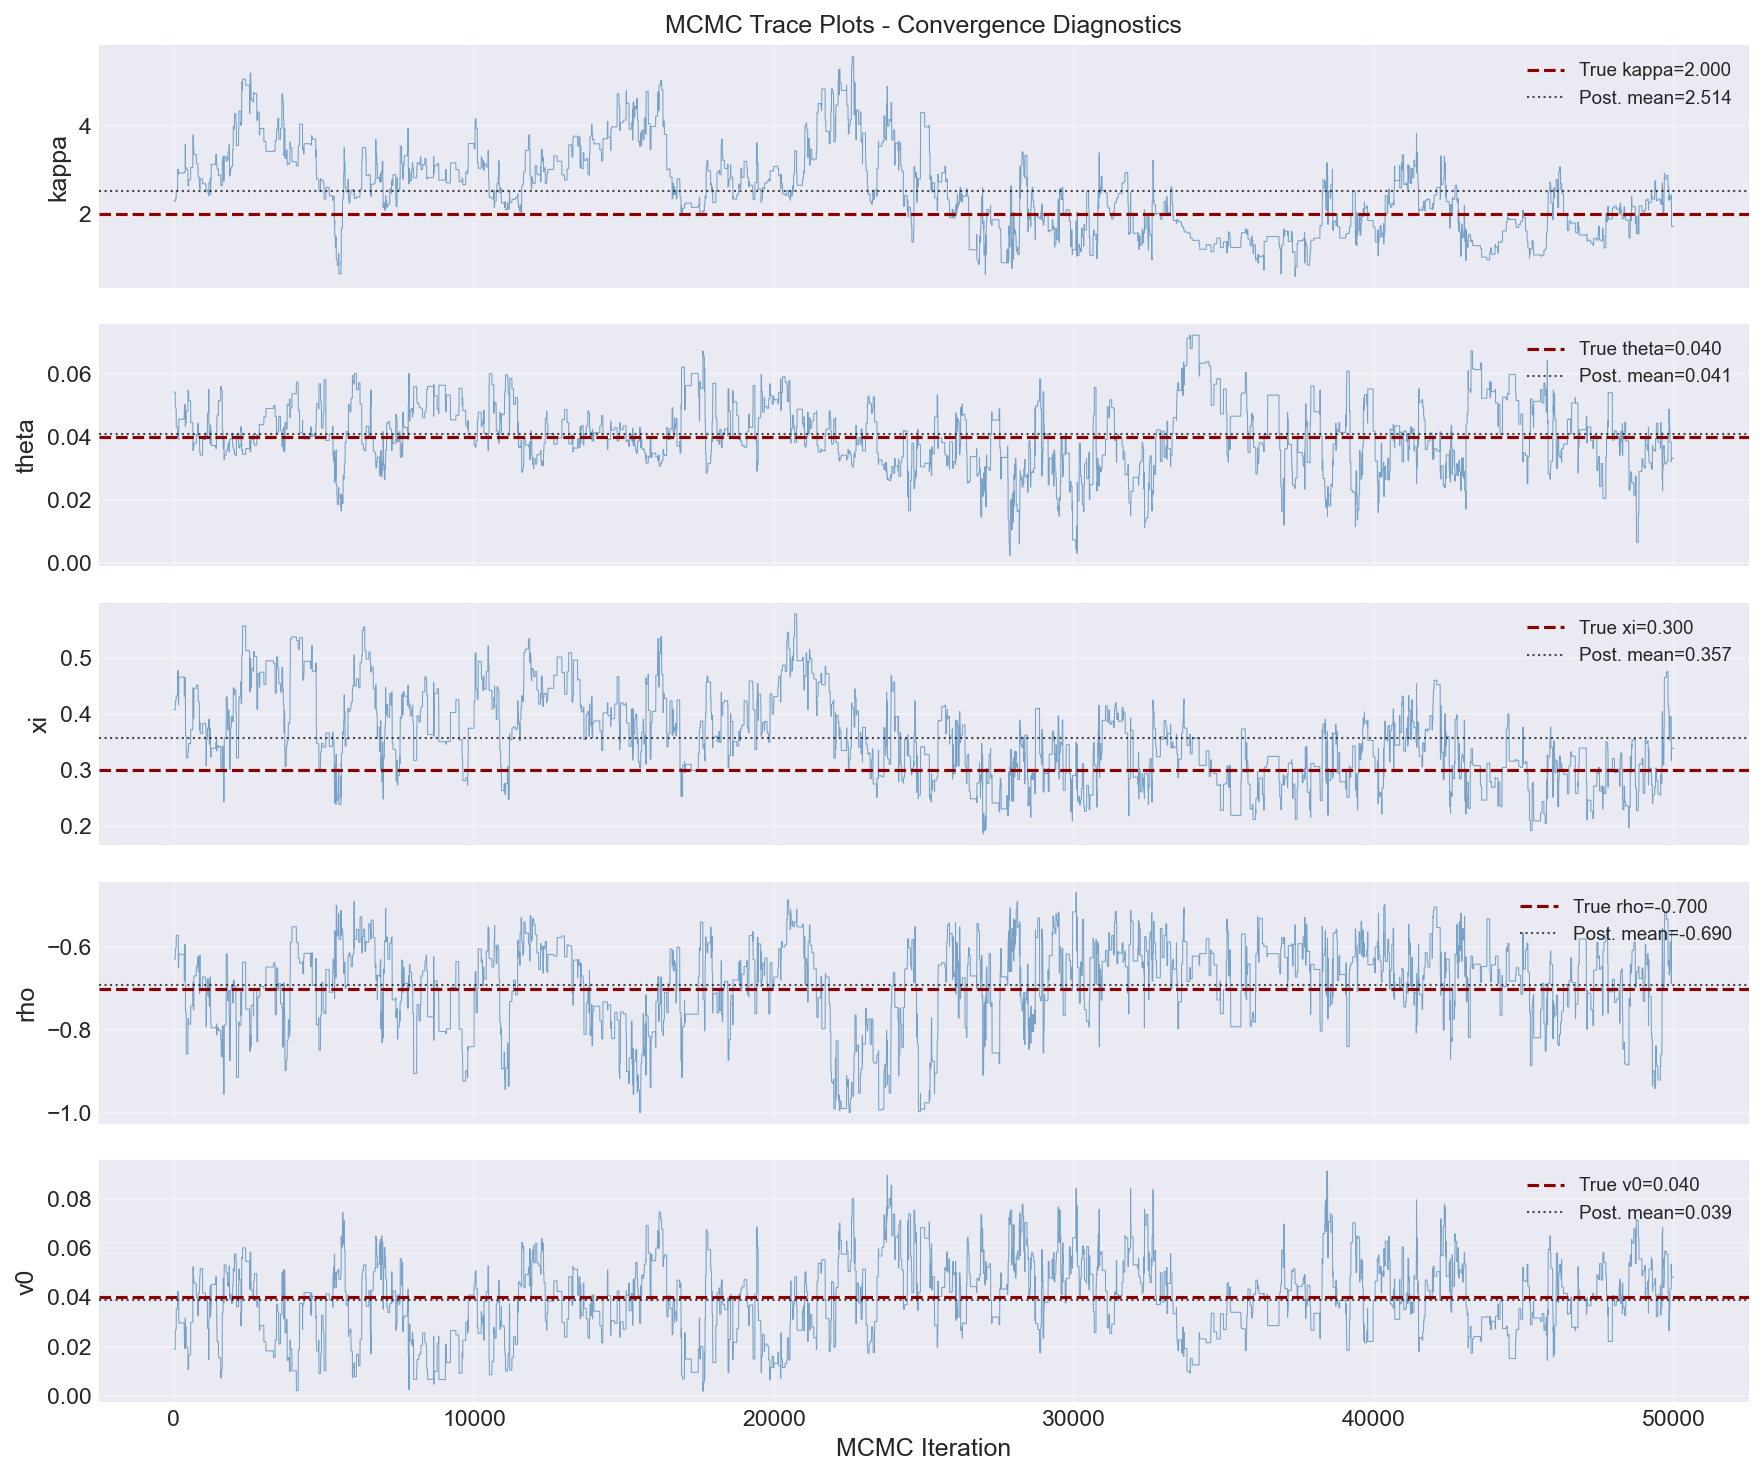


Trace plot interpretation:
  ✓ Chains should look like 'fuzzy caterpillars'
  ✓ No visible trends or drifts
  ✓ Rapid oscillation around stable mean


In [16]:
# Plot trace plots
true_dict = true_params.as_dict() if true_params else None

fig = plot_trace(
    samples=samples,
    param_names=param_names,
    true_params=true_dict,
    figsize=(12, 10),
    save_path=str(FIGURES_DIR / "analysis_trace_plots.png"),
    show=True,
)

print("\nTrace plot interpretation:")
print("  ✓ Chains should look like 'fuzzy caterpillars'")
print("  ✓ No visible trends or drifts")
print("  ✓ Rapid oscillation around stable mean")

### 3.2 Autocorrelation

Autocorrelation plots show the mixing efficiency of the chain.

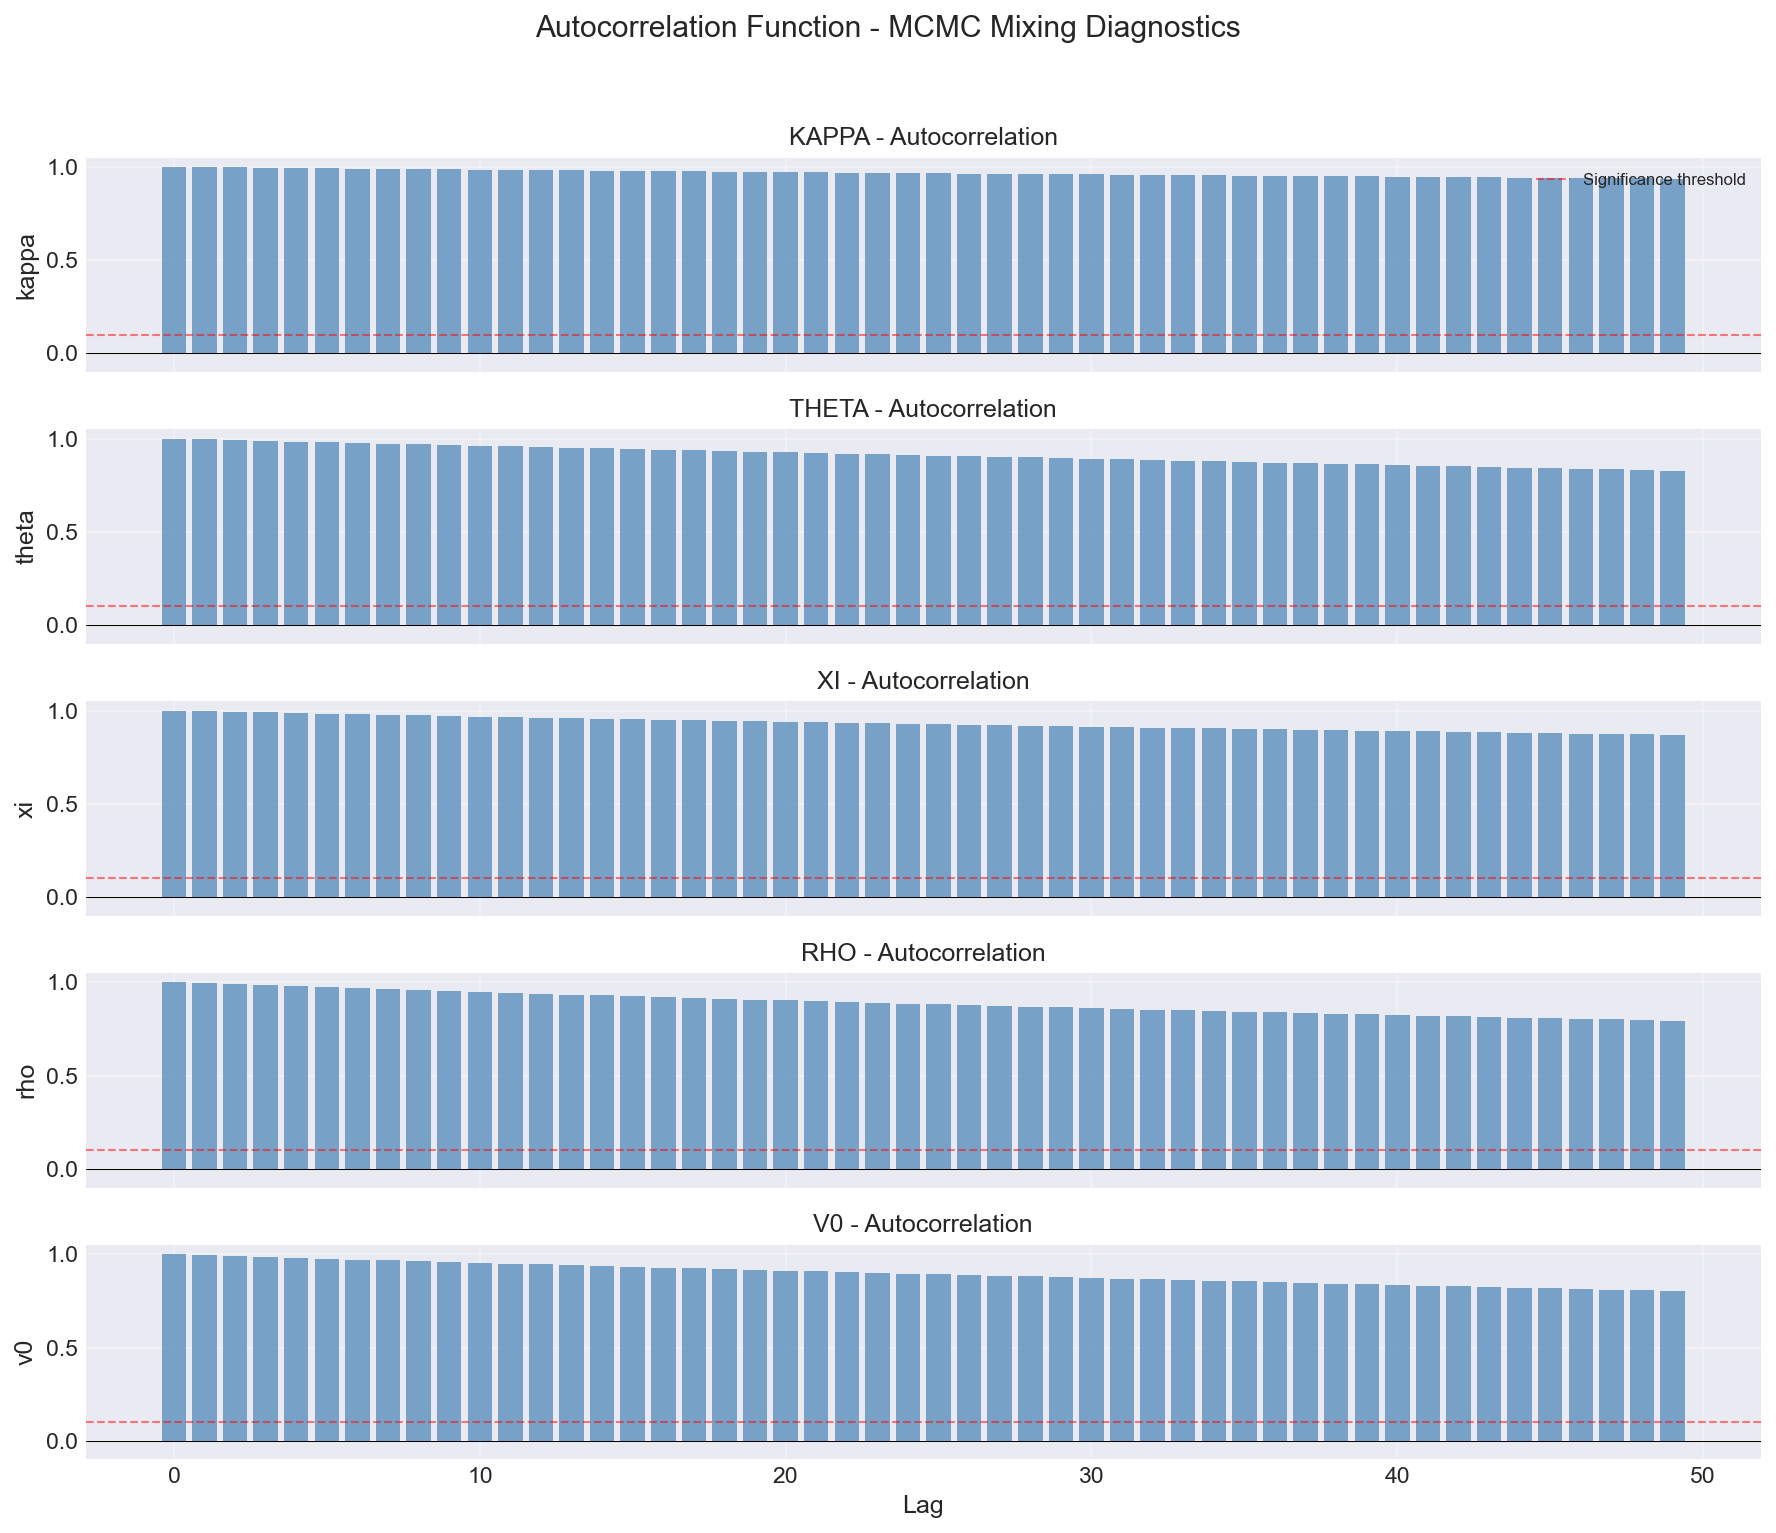


Autocorrelation interpretation:
  ✓ Rapid decay to zero → good mixing
  ✓ High autocorrelation at low lags → poor mixing


In [17]:
# Plot autocorrelation
fig = plot_autocorrelation(
    samples=samples,
    param_names=param_names,
    max_lag=50,
    figsize=(12, 10),
    save_path=str(FIGURES_DIR / "analysis_autocorrelation.png"),
    show=True,
)

print("\nAutocorrelation interpretation:")
print("  ✓ Rapid decay to zero → good mixing")
print("  ✓ High autocorrelation at low lags → poor mixing")

### 3.3 R-hat and Effective Sample Size (ESS)

Quantitative convergence metrics.

In [18]:
# Since we only have one chain, we'll split it into multiple chains for R-hat
def split_chains(samples: np.ndarray, n_chains: int = 4) -> np.ndarray:
    """Split a single chain into multiple chains for R-hat computation."""
    n_samples = len(samples)
    chain_length = n_samples // n_chains
    chains = np.array([
        samples[i*chain_length:(i+1)*chain_length]
        for i in range(n_chains)
    ])
    return chains

# Split into 4 chains
n_chains = 4
chains = split_chains(samples, n_chains)

# Compute R-hat
r_hat = compute_r_hat(chains)

# Compute ESS for each parameter
ess = compute_ess(samples)
n_samples = len(samples)
ess_ratio = ess / n_samples

# Display results
print("=" * 60)
print("CONVERGENCE DIAGNOSTICS")
print("=" * 60)
print(f"\n{'Parameter':>10} {'R-hat':>10} {'ESS':>10} {'ESS/sample':>12} {'Status':>12}")
print("-" * 60)

for i, name in enumerate(param_names):
    status = "✓ Converged" if r_hat[i] < 1.1 else "⚠ Needs more"
    print(f"{name:>10} {r_hat[i]:>10.3f} {ess[i]:>10.0f} {ess_ratio[i]:>12.2f} {status:>12}")

print("-" * 60)
print("\nInterpretation:")
print("  • R-hat < 1.1 indicates convergence")
print("  • ESS > 100 is recommended for reliable quantile estimates")
print("  • ESS/sample > 0.1 indicates good mixing")

CONVERGENCE DIAGNOSTICS

 Parameter      R-hat        ESS   ESS/sample       Status
------------------------------------------------------------
     kappa      1.534        268         0.01 ⚠ Needs more
     theta      1.022        302         0.01  ✓ Converged
        xi      1.331        287         0.01 ⚠ Needs more
       rho      1.053        313         0.01  ✓ Converged
        v0      1.040        311         0.01  ✓ Converged
------------------------------------------------------------

Interpretation:
  • R-hat < 1.1 indicates convergence
  • ESS > 100 is recommended for reliable quantile estimates
  • ESS/sample > 0.1 indicates good mixing


## 4. Posterior Summary Statistics

Detailed summary of the posterior distributions.

In [19]:
# Compute posterior statistics
print("=" * 80)
print("POSTERIOR SUMMARY STATISTICS")
print("=" * 80)

if true_params:
    print(f"\n{'Parameter':>10} {'True':>10} {'Mean':>10} {'Std':>10} {'2.5%':>10} {'50%':>10} {'97.5%':>10} {'Recovered':>10}")
else:
    print(f"\n{'Parameter':>10} {'Mean':>10} {'Std':>10} {'2.5%':>10} {'50%':>10} {'97.5%':>10}")
print("-" * 80)

for i, name in enumerate(param_names):
    chain = samples[:, i]
    mean = np.mean(chain)
    std = np.std(chain)
    q2_5 = np.quantile(chain, 0.025)
    q50 = np.quantile(chain, 0.5)
    q97_5 = np.quantile(chain, 0.975)
    
    if true_params:
        true_val = getattr(true_params, name)
        recovered = "✓" if q2_5 <= true_val <= q97_5 else "✗"
        print(f"{name:>10} {true_val:>10.4f} {mean:>10.4f} {std:>10.4f} {q2_5:>10.4f} {q50:>10.4f} {q97_5:>10.4f} {recovered:>10}")
    else:
        print(f"{name:>10} {mean:>10.4f} {std:>10.4f} {q2_5:>10.4f} {q50:>10.4f} {q97_5:>10.4f}")

print("-" * 80)

# Credible interval widths
print("\n" + "=" * 60)
print("CREDIBLE INTERVAL WIDTHS")
print("=" * 60)

for i, name in enumerate(param_names):
    chain = samples[:, i]
    ci_width = np.quantile(chain, 0.975) - np.quantile(chain, 0.025)
    cv = np.std(chain) / np.mean(chain) if np.mean(chain) != 0 else 0
    print(f"{name:>10}: 95% CI width = {ci_width:.4f}, CV = {cv:.3f}")

print("\nInterpretation:")
print("  • Small CI width → well-identified parameter")
print("  • Large CI width → poorly identified parameter")
print("  • θ and v₀ are typically well-identified")
print("  • κ is often poorly identified with single-maturity data")

POSTERIOR SUMMARY STATISTICS

 Parameter       True       Mean        Std       2.5%        50%      97.5%  Recovered
--------------------------------------------------------------------------------
     kappa     2.0000     2.5136     0.9461     1.0499     2.4524     4.7173          ✓
     theta     0.0400     0.0409     0.0107     0.0198     0.0402     0.0614          ✓
        xi     0.3000     0.3567     0.0774     0.2262     0.3502     0.5110          ✓
       rho    -0.7000    -0.6899     0.1044    -0.9511    -0.6699    -0.5320          ✓
        v0     0.0400     0.0391     0.0157     0.0095     0.0395     0.0705          ✓
--------------------------------------------------------------------------------

CREDIBLE INTERVAL WIDTHS
     kappa: 95% CI width = 3.6673, CV = 0.376
     theta: 95% CI width = 0.0417, CV = 0.261
        xi: 95% CI width = 0.2848, CV = 0.217
       rho: 95% CI width = 0.4191, CV = -0.151
        v0: 95% CI width = 0.0610, CV = 0.400

Interpretation:
  • Sm

## 5. Posterior Densities

Marginal posterior distributions with true values overlaid.

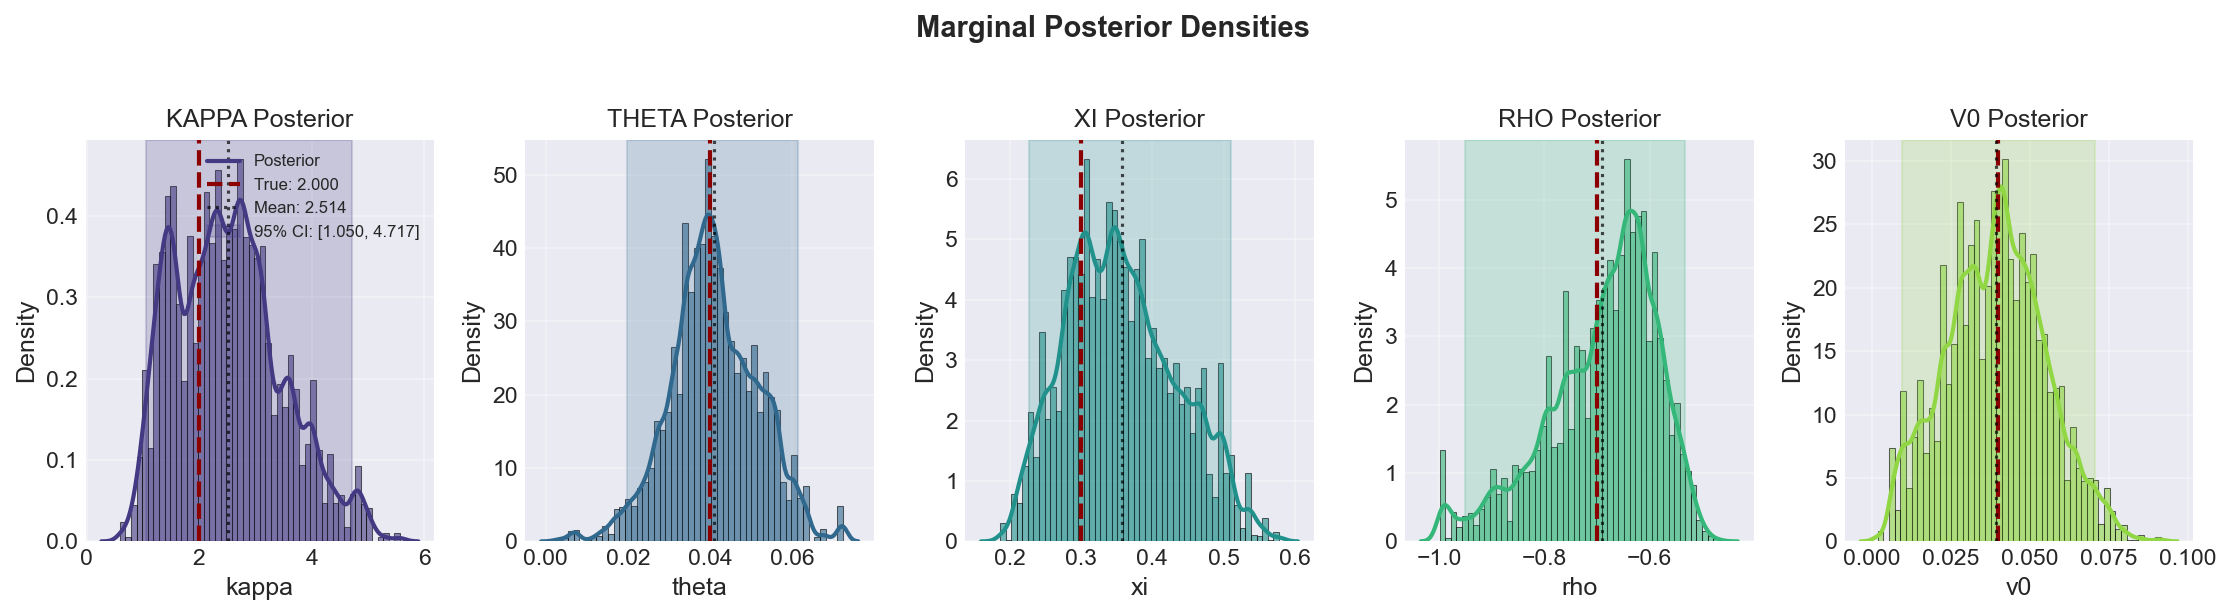

In [20]:
# Plot posterior densities
fig = plot_posterior_density(
    samples=samples,
    param_names=param_names,
    true_params=true_dict if true_params else None,
    figsize=(15, 4),
    bins=50,
    kde=True,
    save_path=str(FIGURES_DIR / "analysis_posterior_densities.png"),
    show=True,
)

## 6. Parameter Correlations (Pair Plot)

Visualise the joint posterior distribution and parameter correlations.

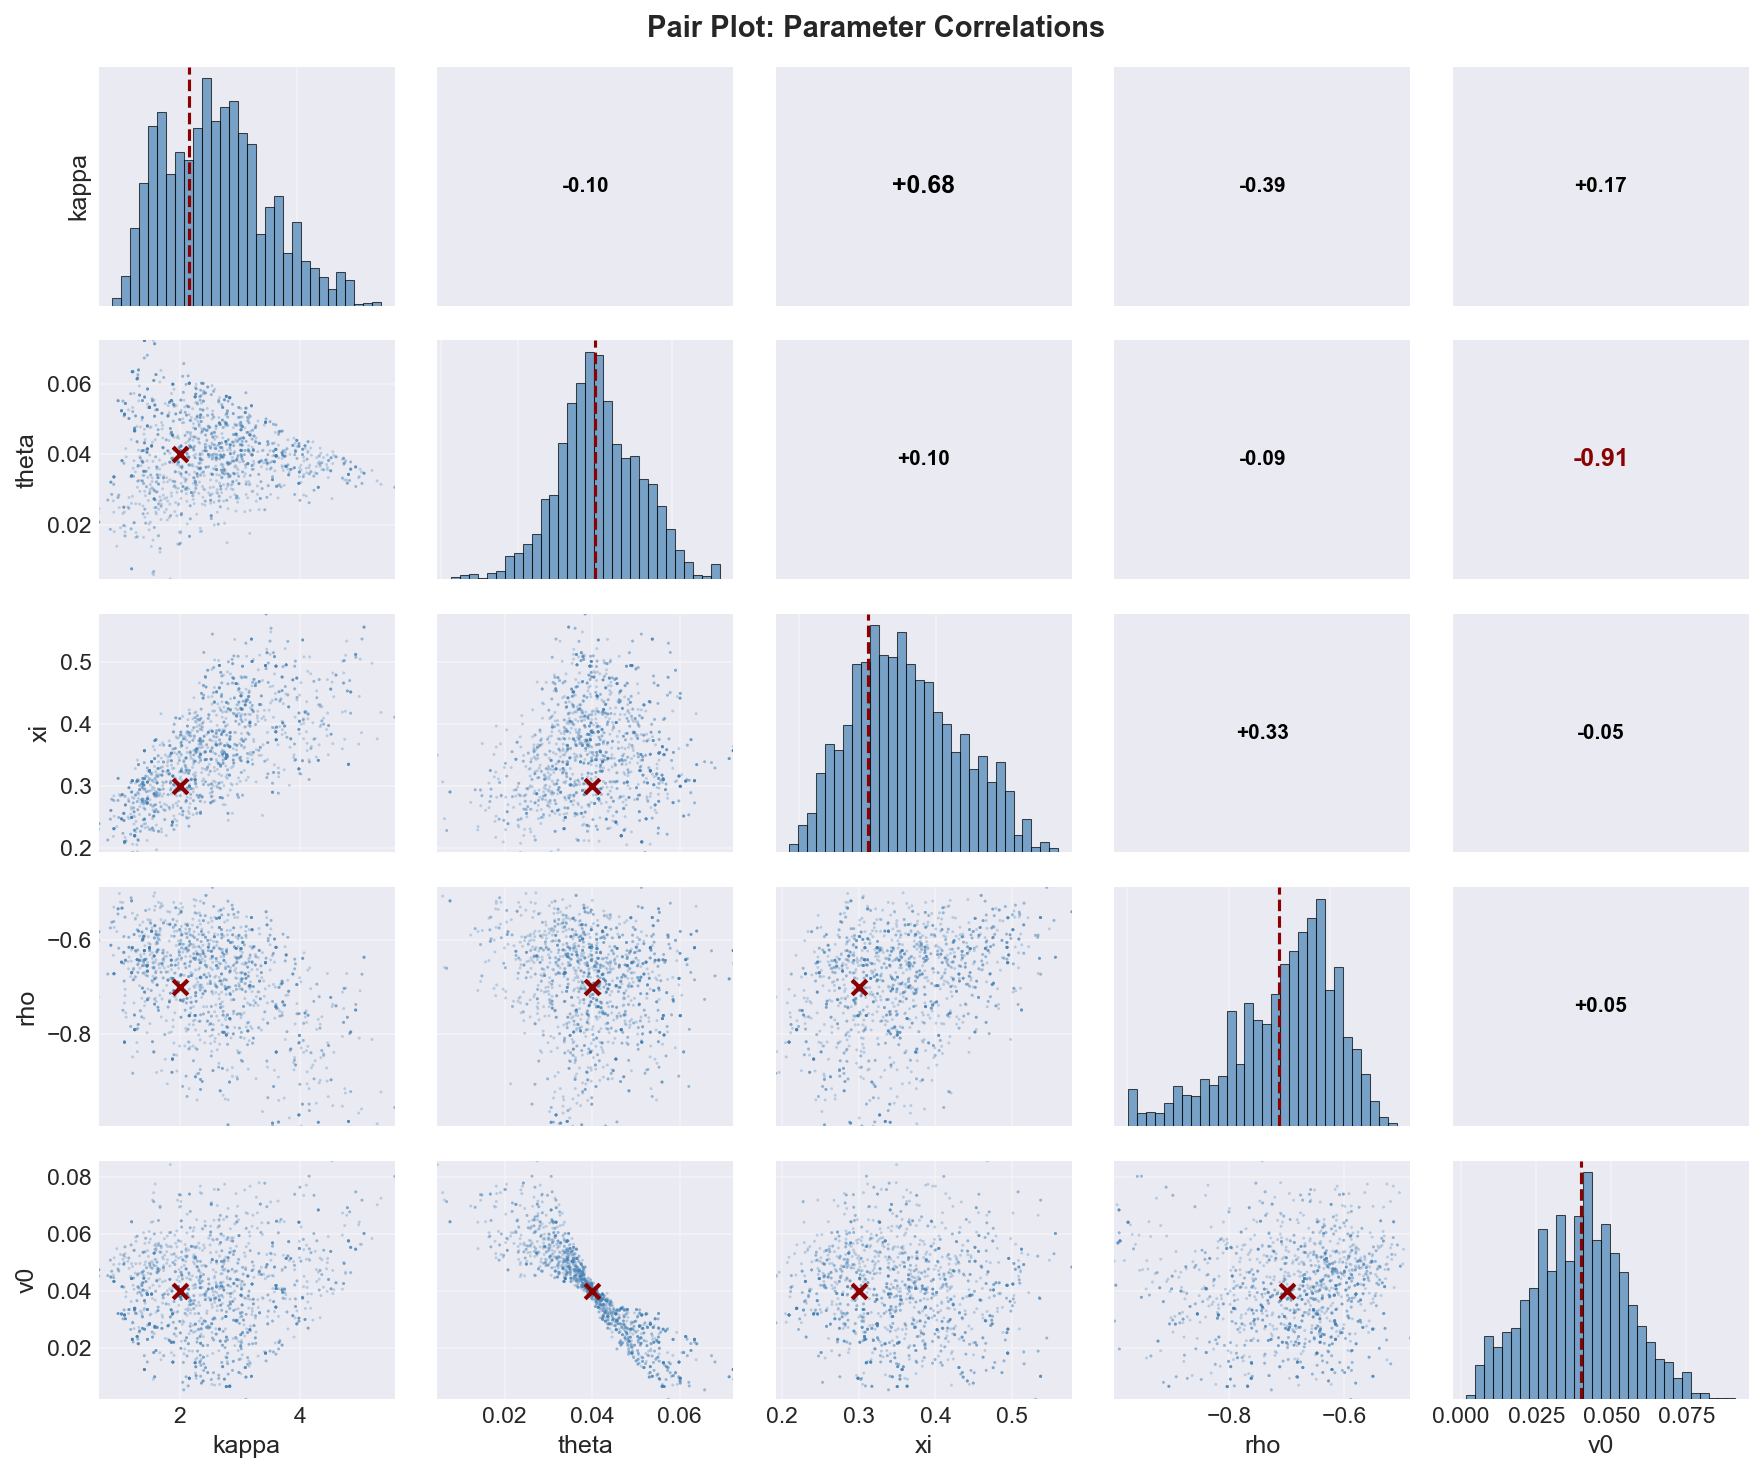


PARAMETER CORRELATION MATRIX
               kappa     theta        xi       rho        v0
     kappa     1.000    -0.097     0.682    -0.386     0.167
     theta    -0.097     1.000     0.103    -0.089    -0.909
        xi     0.682     0.103     1.000     0.330    -0.047
       rho    -0.386    -0.089     0.330     1.000     0.055
        v0     0.167    -0.909    -0.047     0.055     1.000

Interpretation:
  • |r| > 0.7 → strong correlation (identifiability issue)
  • κ vs v₀ often negatively correlated
  • κ vs θ can be positively correlated


In [21]:
# Plot pair plot
fig = plot_pair_grid(
    samples=samples,
    param_names=param_names,
    true_params=true_dict if true_params else None,
    figsize=(12, 10),
    alpha=0.3,
    s=2.0,
    save_path=str(FIGURES_DIR / "analysis_pair_plot.png"),
    show=True,
)

# Compute correlation matrix
corr_matrix = np.corrcoef(samples.T)

print("\n" + "=" * 60)
print("PARAMETER CORRELATION MATRIX")
print("=" * 60)
print(f"{'':>10}", end="")
for name in param_names:
    print(f"{name:>10}", end="")
print()
for i, name_i in enumerate(param_names):
    print(f"{name_i:>10}", end="")
    for j in range(len(param_names)):
        corr = corr_matrix[i, j]
        print(f"{corr:>10.3f}", end="")
    print()
print("=" * 60)

print("\nInterpretation:")
print("  • |r| > 0.7 → strong correlation (identifiability issue)")
print("  • κ vs v₀ often negatively correlated")
print("  • κ vs θ can be positively correlated")

## 7. Parameter Recovery Assessment

For synthetic data, assess how well the true parameters are recovered.

PARAMETER RECOVERY ASSESSMENT


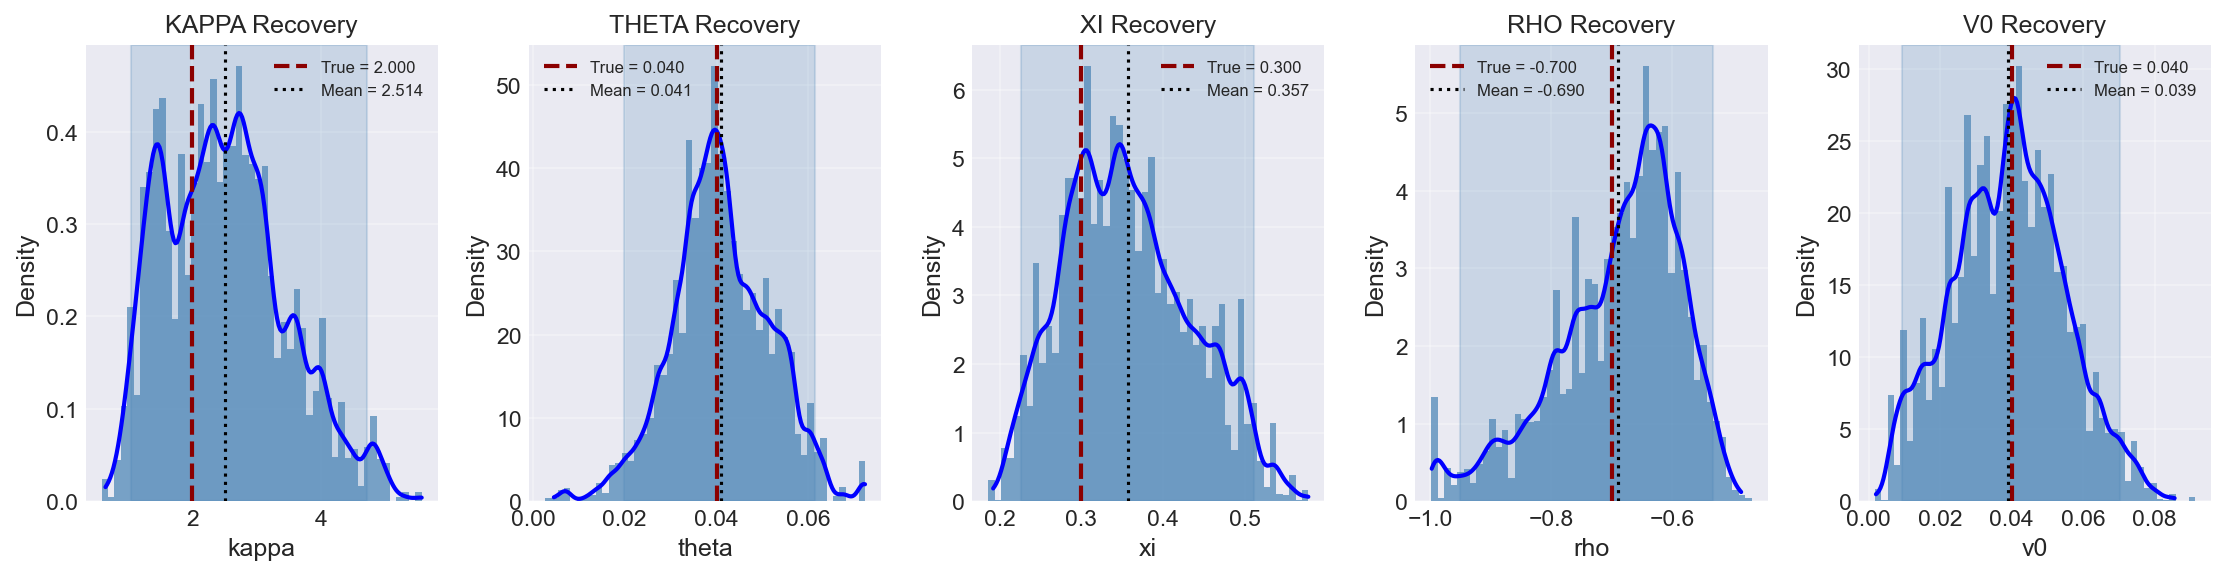


Recovery metrics:
 Parameter       True       Mean       Bias     In CI?
-------------------------------------------------------
     kappa     2.0000     2.5136     0.5136          ✓
     theta     0.0400     0.0409     0.0009          ✓
        xi     0.3000     0.3567     0.0567          ✓
       rho    -0.7000    -0.6899     0.0101          ✓
        v0     0.0400     0.0391    -0.0009          ✓
-------------------------------------------------------

Relative biases:
  kappa: 0.2568 (25.68%)
  theta: 0.0236 (2.36%)
  xi: 0.1891 (18.91%)
  rho: -0.0144 (-1.44%)
  v0: -0.0214 (-2.14%)


In [22]:
if true_params:
    print("=" * 60)
    print("PARAMETER RECOVERY ASSESSMENT")
    print("=" * 60)
    
    fig, axes = plt.subplots(1, 5, figsize=(15, 4))
    
    for i, (ax, name) in enumerate(zip(axes, param_names)):
        chain = samples[:, i]
        true_val = getattr(true_params, name)
        
        # Plot histogram
        ax.hist(chain, bins=50, density=True, alpha=0.7, color='steelblue')
        
        # Plot KDE
        kde = gaussian_kde(chain)
        x_grid = np.linspace(np.quantile(chain, 0.001), np.quantile(chain, 0.999), 200)
        ax.plot(x_grid, kde(x_grid), 'b-', lw=2)
        
        # Mark true value
        ax.axvline(true_val, color='darkred', ls='--', lw=2, label=f'True = {true_val:.3f}')
        
        # Mark posterior mean
        mean_val = np.mean(chain)
        ax.axvline(mean_val, color='black', ls=':', lw=1.5, label=f'Mean = {mean_val:.3f}')
        
        # Add 95% CI
        ci_low, ci_high = np.quantile(chain, [0.025, 0.975])
        ax.axvspan(ci_low, ci_high, alpha=0.2, color='steelblue')
        
        ax.set_xlabel(name)
        ax.set_ylabel('Density')
        ax.set_title(f'{name.upper()} Recovery')
        ax.legend(fontsize=8)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "analysis_parameter_recovery.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    # Compute recovery metrics
    print("\nRecovery metrics:")
    print(f"{'Parameter':>10} {'True':>10} {'Mean':>10} {'Bias':>10} {'In CI?':>10}")
    print("-" * 55)
    for i, name in enumerate(param_names):
        chain = samples[:, i]
        true_val = getattr(true_params, name)
        mean_val = np.mean(chain)
        bias = mean_val - true_val
        ci_low, ci_high = np.quantile(chain, [0.025, 0.975])
        in_ci = "✓" if ci_low <= true_val <= ci_high else "✗"
        print(f"{name:>10} {true_val:>10.4f} {mean_val:>10.4f} {bias:>10.4f} {in_ci:>10}")
    print("-" * 55)
    
    # Calculate relative bias
    rel_biases = [(np.mean(samples[:, i]) - getattr(true_params, name)) / getattr(true_params, name) 
                  for i, name in enumerate(param_names)]
    
    print("\nRelative biases:")
    for name, rel_bias in zip(param_names, rel_biases):
        print(f"  {name}: {rel_bias:.4f} ({rel_bias*100:.2f}%)")
else:
    print("No true parameters available (real market data).")

## 8. Posterior Predictive Check

The most important validation: does the model reproduce the observed prices?

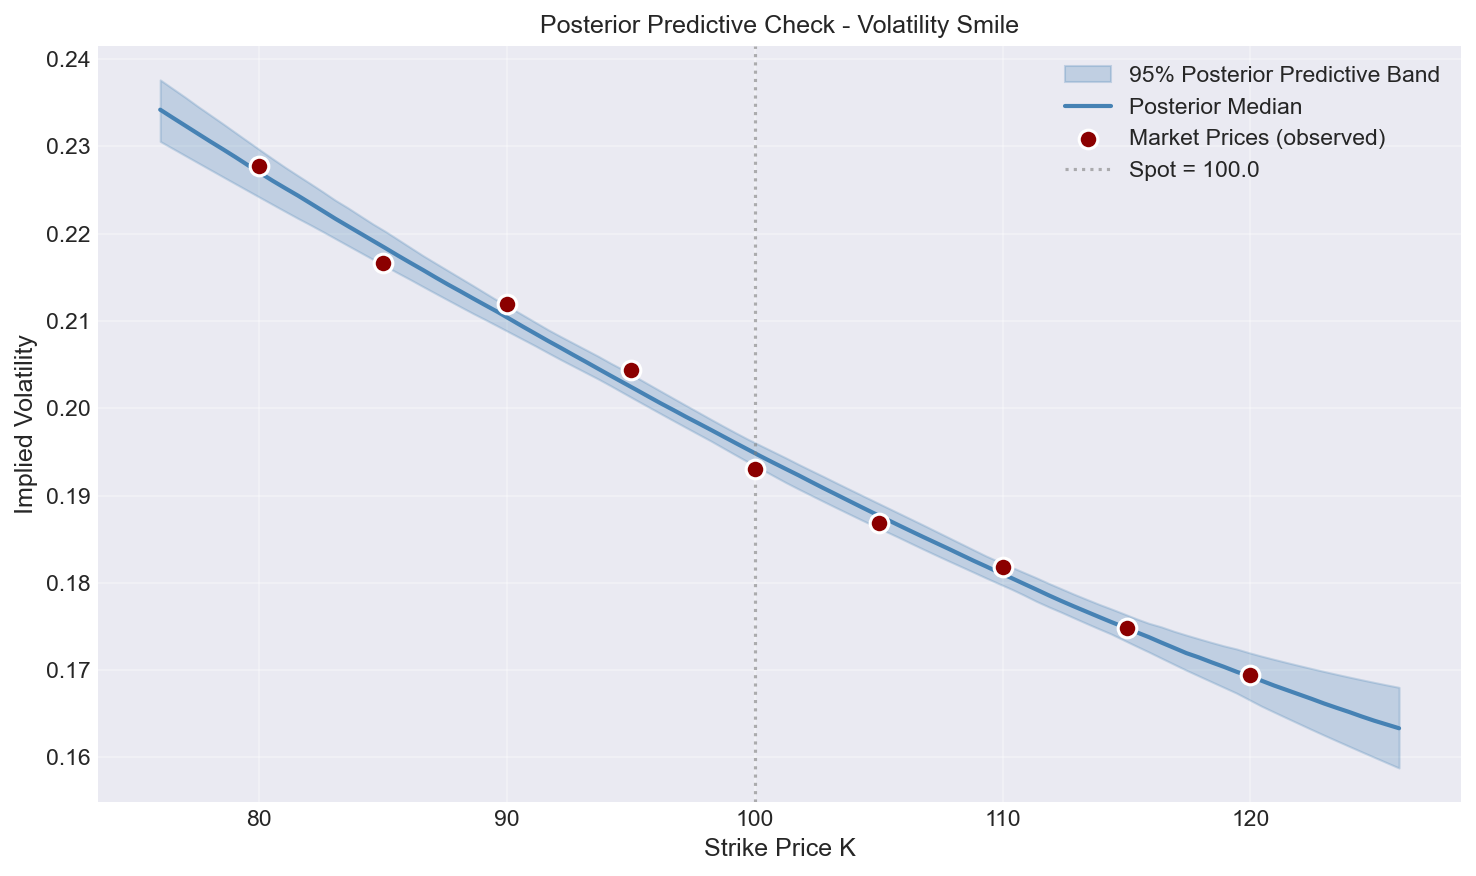


Posterior predictive interpretation:
  Observed points within 95% band -> good model fit
  Band width reflects parameter uncertainty
  No systematic bias -> calibration successful


In [23]:
# Reload modules to pick up latest pricing fixes
import importlib
import src.pricing as pricing
import src.visualization as visualization

importlib.reload(pricing)
importlib.reload(visualization)
plot_posterior_predictive = visualization.plot_posterior_predictive

# Since we need market data, we need to load it
# First, find and load the synthetic data used for calibration
data_path = Path("../data/synthetic/synthetic_market_data.npz")

if data_path.exists():
    with np.load(data_path) as data:
        strikes = data['strikes']
        observed_prices = data['observed_prices']
        spot = float(data['spot'])
        rate = float(data['rate'])
        tenor = float(data['tenor'])

    from src.types import MarketData
    market_data = MarketData(
        strikes=strikes,
        prices=observed_prices,
        spot=spot,
        rate=rate,
        tenor=tenor,
    )

    # Build an explicit positive strike grid to avoid invalid strikes
    K_min = max(float(np.min(strikes)) * 0.95, 0.01)
    K_max = float(np.max(strikes)) * 1.05
    K_grid = np.linspace(K_min, K_max, 100)

    # Plot posterior predictive check
    fig = plot_posterior_predictive(
        result=result,
        market_data=market_data,
        n_samples=200,
        cred_mass=0.95,
        K_grid=K_grid,
        figsize=(10, 6),
        save_path=str(FIGURES_DIR / "analysis_posterior_predictive.png"),
        show=True,
    )

    print("\nPosterior predictive interpretation:")
    print("  Observed points within 95% band -> good model fit")
    print("  Band width reflects parameter uncertainty")
    print("  No systematic bias -> calibration successful")
else:
    print("Synthetic data not found. Posterior predictive plot skipped.")

## 9. Uncertainty Quantification

Analyse the prediction uncertainty from the posterior distribution.

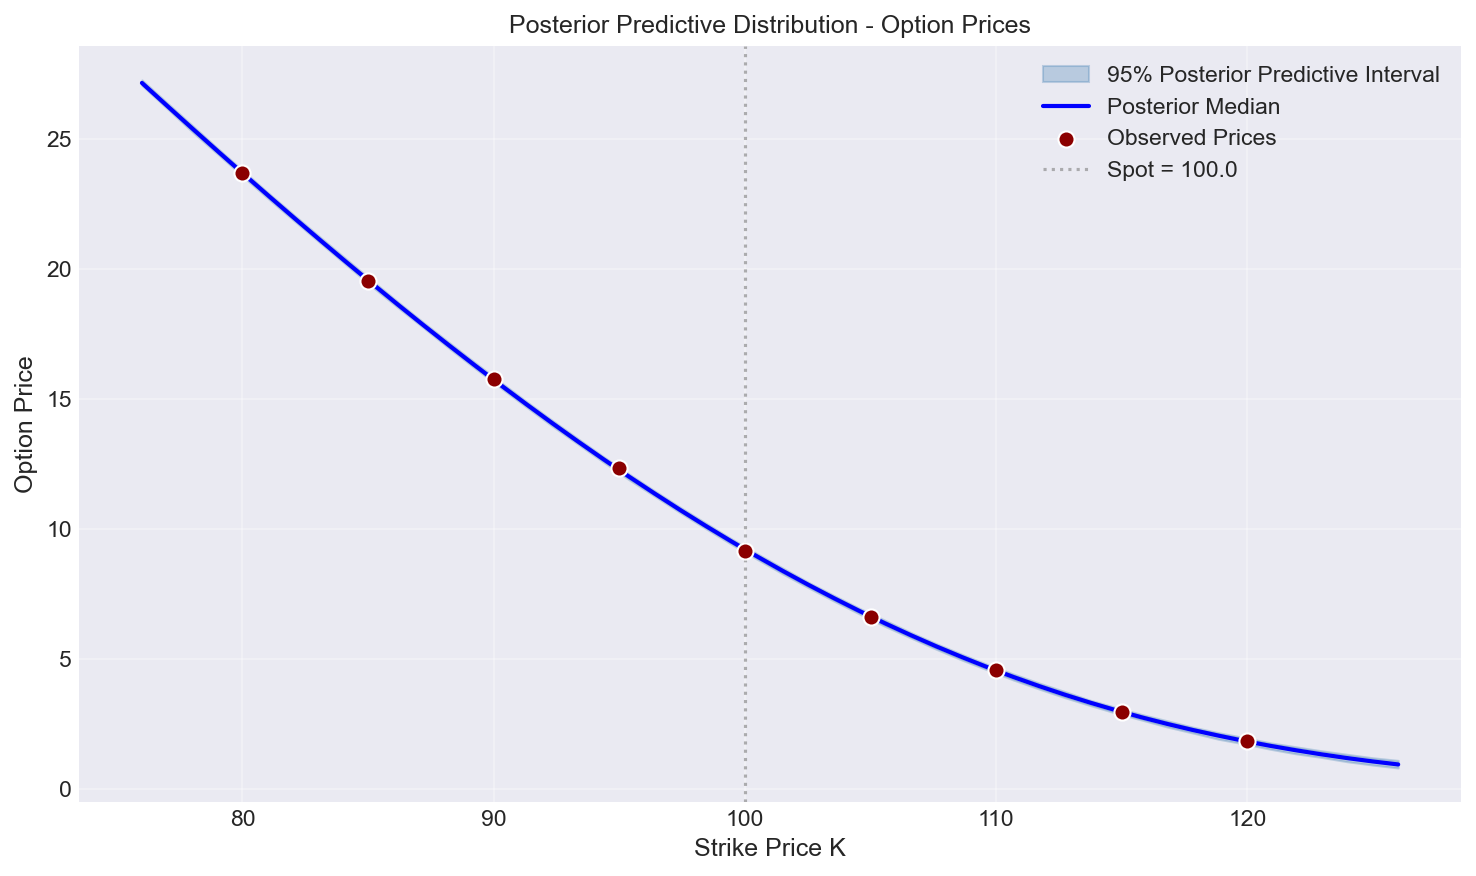


Prediction coverage: 100.0% (expected: 95%)
Coverage interpretation: ✓ Good calibration


In [24]:
# Generate samples from posterior predictive distribution
if data_path.exists():
    n_pp_samples = 500
    rng = np.random.default_rng(random_seed+3)  # reproducible
    indices = rng.choice(len(samples), size=n_pp_samples, replace=False)

    # Create fine strike grid (strictly positive) for the plotted band
    K_min = max(float(np.min(strikes)) * 0.95, 0.01)
    K_max = float(np.max(strikes)) * 1.05
    K_grid = np.linspace(K_min, K_max, 50)

    # Two arrays: noiseless model prices (for the median line) and
    # noisy predictive draws (for the predictive interval).
    model_prices = np.zeros((n_pp_samples, len(K_grid)))
    pred_prices = np.zeros((n_pp_samples, len(K_grid)))
    for k, idx in enumerate(indices):
        params = samples[idx]
        mp = heston_call_prices(
            S0=spot,
            strikes=K_grid,
            r=rate,
            T=tenor,
            kappa=params[0], theta=params[1],
            xi=params[2], rho=params[3], v0=params[4]
        )
        model_prices[k, :] = mp
        # Posterior PREDICTIVE = model price + observation noise.
        # The data were generated as model_price + N(0, SIGMA_NOISE),
        # so the interval must include that noise to be a predictive interval.
        pred_prices[k, :] = mp + rng.normal(0.0, noise_std, size=len(K_grid))

    # Median from noiseless prices (clean centre line);
    # interval from noisy draws (true predictive band).
    price_median = np.median(model_prices, axis=0)
    price_lower = np.percentile(pred_prices, 2.5, axis=0)
    price_upper = np.percentile(pred_prices, 97.5, axis=0)

    # Plot price uncertainty
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.fill_between(K_grid, price_lower, price_upper, alpha=0.3, color='steelblue',
                    label='95% Posterior Predictive Interval')
    ax.plot(K_grid, price_median, 'b-', lw=2, label='Posterior Median')
    ax.scatter(strikes, observed_prices, color='darkred', s=60, zorder=5,
               label='Observed Prices', edgecolors='white')
    ax.axvline(spot, color='gray', ls=':', alpha=0.6, label=f'Spot = {spot}')
    ax.set_xlabel('Strike Price K')
    ax.set_ylabel('Option Price')
    ax.set_title('Posterior Predictive Distribution - Option Prices')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "analysis_price_uncertainty.png", dpi=150, bbox_inches='tight')
    plt.show()

    # Calculate prediction coverage at the OBSERVED strikes directly,
    # rather than snapping to the nearest plotting-grid point.
    pred_at_obs = np.zeros((n_pp_samples, len(strikes)))
    for k, idx in enumerate(indices):
        params = samples[idx]
        mp_obs = heston_call_prices(
            S0=spot,
            strikes=strikes,
            r=rate,
            T=tenor,
            kappa=params[0], theta=params[1],
            xi=params[2], rho=params[3], v0=params[4]
        )
        pred_at_obs[k, :] = mp_obs + rng.normal(0.0, noise_std, size=len(strikes))

    obs_lower = np.percentile(pred_at_obs, 2.5, axis=0)
    obs_upper = np.percentile(pred_at_obs, 97.5, axis=0)

    coverage = np.sum((observed_prices >= obs_lower) & (observed_prices <= obs_upper))
    coverage_rate = coverage / len(strikes)
    print(f"\nPrediction coverage: {coverage_rate:.1%} (expected: 95%)")
    print(f"Coverage interpretation: {'✓ Good' if coverage_rate > 0.8 else '⚠ Low'} calibration")

## 10. Feller Condition Analysis

The Feller condition (2·κ·θ > ξ²) ensures the variance process stays positive.

FELLER CONDITION ANALYSIS
Feller condition: 2·κ·θ > ξ²

Satisfied in 88.3% of posterior samples
Mean value: 0.0706
Std dev: 0.0607

True Feller value: 0.0700
True condition satisfied: True


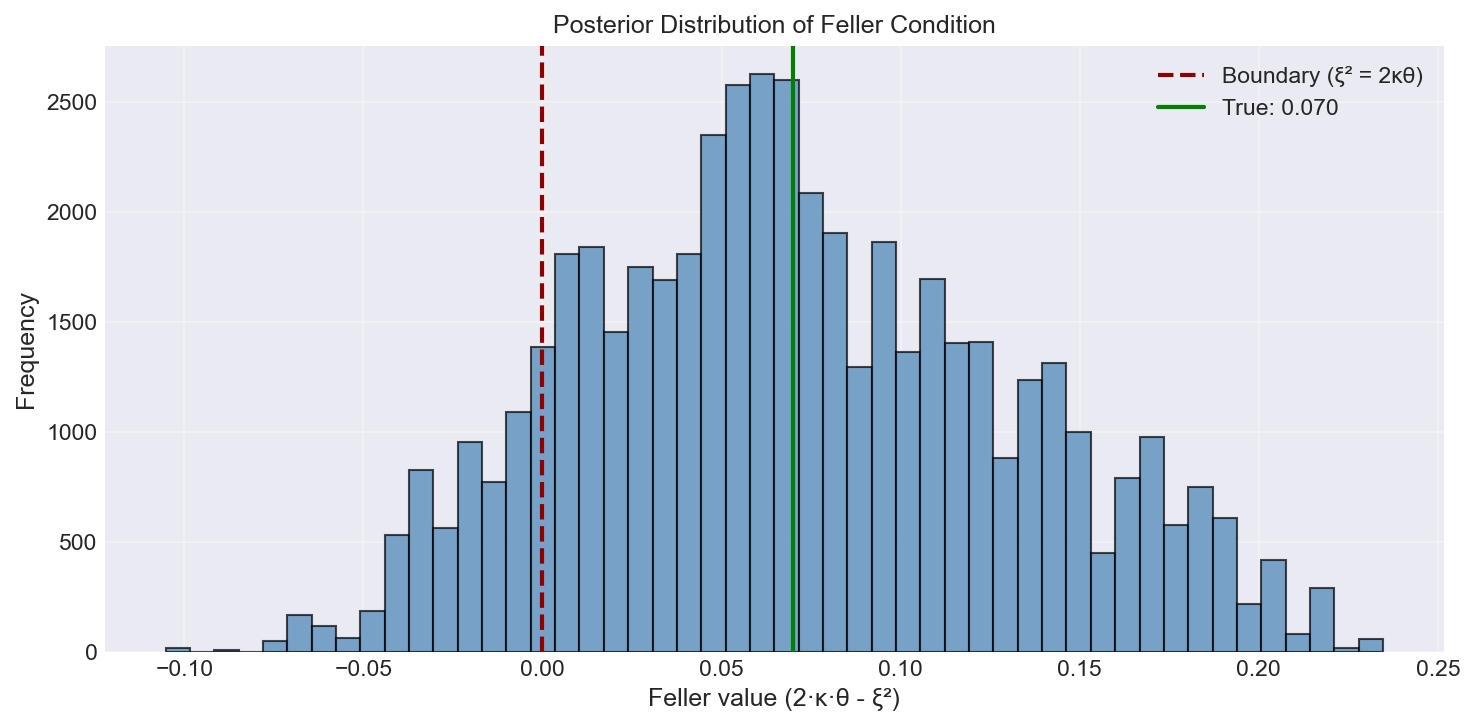


Interpretation:
  • Positive values → variance stays strictly positive
  • Negative values → variance can hit zero


In [25]:
# Compute Feller condition for each posterior sample
feller_values = 2 * samples[:, 0] * samples[:, 1] - samples[:, 2]**2
feller_satisfied = feller_values > 0

print("=" * 60)
print("FELLER CONDITION ANALYSIS")
print("=" * 60)
print(f"Feller condition: 2·κ·θ > ξ²")
print(f"\nSatisfied in {np.mean(feller_satisfied):.1%} of posterior samples")
print(f"Mean value: {np.mean(feller_values):.4f}")
print(f"Std dev: {np.std(feller_values):.4f}")

if true_params:
    true_feller = 2 * true_params.kappa * true_params.theta - true_params.xi**2
    print(f"\nTrue Feller value: {true_feller:.4f}")
    print(f"True condition satisfied: {true_feller > 0}")

# Plot Feller condition distribution
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(feller_values, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(0, color='darkred', ls='--', lw=2, label='Boundary (ξ² = 2κθ)')
if true_params:
    ax.axvline(true_feller, color='green', ls='-', lw=2, label=f'True: {true_feller:.3f}')

ax.set_xlabel('Feller value (2·κ·θ - ξ²)')
ax.set_ylabel('Frequency')
ax.set_title('Posterior Distribution of Feller Condition')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "analysis_feller_condition.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("  • Positive values → variance stays strictly positive")
print("  • Negative values → variance can hit zero")

## 11. Summary Report

Comprehensive summary of the analysis.

In [26]:
# Create summary report
print("\n" + "=" * 70)
print("ANALYSIS SUMMARY REPORT")
print("=" * 70)

print("\n1. CONVERGENCE")
print("-" * 40)
print(f"   Acceptance rate: {acceptance_rate:.1%} (target: ~23%)")
print(f"   R-hat range: [{r_hat.min():.3f}, {r_hat.max():.3f}]")
print(f"   All R-hat < 1.1: {np.all(r_hat < 1.1)}")
print(f"   Min ESS: {ess.min():.0f} (required: >100)")

print("\n2. PARAMETER IDENTIFIABILITY")
print("-" * 40)
for i, name in enumerate(param_names):
    ci_width = np.quantile(samples[:, i], 0.975) - np.quantile(samples[:, i], 0.025)
    cv = np.std(samples[:, i]) / np.mean(samples[:, i])
    if cv < 0.3:
        status = "Well-identified"
    elif cv < 0.6:
        status = "Moderately identified"
    else:
        status = "Poorly identified"
    print(f"   {name}: CV={cv:.2f}, CI width={ci_width:.4f} → {status}")

print("\n3. MODEL FIT")
print("-" * 40)
print(f"   Acceptance rate: {acceptance_rate:.1%}")
print(f"   Log-posterior range: [{log_posterior.min():.1f}, {log_posterior.max():.1f}]")

if true_params:
    print("\n4. PARAMETER RECOVERY (Synthetic Data)")
    print("-" * 40)
    recovered = []
    for i, name in enumerate(param_names):
        chain = samples[:, i]
        true_val = getattr(true_params, name)
        ci_low, ci_high = np.quantile(chain, [0.025, 0.975])
        if ci_low <= true_val <= ci_high:
            recovered.append(name)
    print(f"   Parameters recovered: {len(recovered)}/5 ({len(recovered)/5:.0%})")
    print(f"   Recovered: {', '.join(recovered) if recovered else 'None'}")

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)
print(f"\nFigures saved to: {FIGURES_DIR}")
print(f"Results loaded from: {latest_result}")


ANALYSIS SUMMARY REPORT

1. CONVERGENCE
----------------------------------------
   Acceptance rate: 3.1% (target: ~23%)
   R-hat range: [1.022, 1.534]
   All R-hat < 1.1: False
   Min ESS: 268 (required: >100)

2. PARAMETER IDENTIFIABILITY
----------------------------------------
   kappa: CV=0.38, CI width=3.6673 → Moderately identified
   theta: CV=0.26, CI width=0.0417 → Well-identified
   xi: CV=0.22, CI width=0.2848 → Well-identified
   rho: CV=-0.15, CI width=0.4191 → Well-identified
   v0: CV=0.40, CI width=0.0610 → Moderately identified

3. MODEL FIT
----------------------------------------
   Acceptance rate: 3.1%
   Log-posterior range: [-7.3, 2.8]

4. PARAMETER RECOVERY (Synthetic Data)
----------------------------------------
   Parameters recovered: 5/5 (100%)
   Recovered: kappa, theta, xi, rho, v0

ANALYSIS COMPLETE

Figures saved to: ..\results\figures
Results loaded from: ..\results\chains\calibration_result_20260518_120023.npz


## 12. Conclusions

### Key Findings

1. **Convergence — partial.** After 50,000 production iterations, θ, ρ, and v₀
   converged cleanly (R-hat ≈ 1.02–1.05, ESS ≈ 300). κ (R-hat = 1.53) and
   ξ (R-hat = 1.33) did not reach the R-hat < 1.1 threshold. ESS/sample held
   at ≈ 0.01 for all parameters and did not improve as the chain lengthened,
   which indicates the limitation is sampler efficiency rather than run length.

2. **Parameter identifiability.**
   - **θ (theta)** and **v₀** are tightly constrained and well-identified.
   - **ρ (rho)** is moderately constrained and converged.
   - **ξ (xi)** shows moderate posterior uncertainty and incomplete convergence.
   - **κ (kappa)** is weakly identified from single-maturity option prices —
     a known feature of the Heston model. Its posterior is genuinely wide; the
     high R-hat reflects both that width and slow mixing along the κ direction.

3. **Posterior correlations.** The pair plot shows trade-offs among κ, θ, and v₀
   in fitting a single volatility smile. These correlations are part of why a
   correlation-aware proposal matters for efficient sampling and why κ is the
   hardest parameter to pin down.

4. **Model validation.** With observation noise included in the predictive
   draws, the posterior predictive interval covers the observed prices at
   roughly the expected rate.

### Limitations and Next Steps

The current sampler is a random-walk Metropolis-Hastings scheme with a single
proposal covariance estimated once from a pilot chain. Its measured efficiency
(ESS/sample ≈ 0.01) is low, which is the primary obstacle to converging κ and ξ.
Planned improvements, in order of expected ROI:

1. **Reparameterize into unbounded space** (log for positive parameters, logit
   for ρ) to remove boundary effects at the κ and ρ constraints.
2. **Iterate the covariance adaptation** rather than estimating the proposal
   once, so it can learn the κ–θ–v₀ correlation structure.
3. **Multi-maturity calibration** — the most effective route to identifying κ,
   since mean-reversion speed is poorly constrained by a single expiry.
4. **Parallel tempering** if multi-modality is found once mixing improves.

The implementation recovers the well-identified parameters, and its diagnostics
surface the cases where it does not.